In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Agriculture case — What does “shape” mean in a table?

## Start without subject knowledge

A wheat kernel is an individual object. A measurement turns one property of that object into a number. A row collects measurements for one kernel; a column repeats a particular measurement across kernels. A class label names a category, not an amount. Subtracting class 1 from class 3 does not define a meaningful physical difference.

The included UCI Seeds snapshot has 210 rows, seven geometric measurements and three integer class labels, with 70 rows per label. UCI describes X-ray-derived measurements of Kama, Rosa and Canadian kernels. We retain the source integers rather than guess the integer-to-name mapping. The original radiographs are not included. These are observed extracted features, not simulated points and not a segmentation benchmark. [Provider and DOI](https://archive.ics.uci.edu/dataset/236/seeds).

**Learning objective:** distinguish a measurement, a constructed geometric feature, a metric-dependent descriptor, and a topological invariant. Then perform a small classification experiment without confusing its score with agricultural validation.



In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/shape_lab').is_dir())
if str(ROOT / 'src') not in sys.path: sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shape_lab.evidence_v7 import load_snapshot, conformal_rank, conformal_radius, coverage, overlap_report
from shape_lab.display import show_and_save, save_json

OUT=ROOT/'reports/v7/seeds';OUT.mkdir(parents=True,exist_ok=True)
table,meta=load_snapshot('seeds')
print(meta['observation']);print(table.shape)
display(table.head())


One wheat kernel described by seven extracted geometric measurements; original X-ray images are not bundled.
(210, 9)


,source_id,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,variety
0,1,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,3,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


## First check: labels and a geometric identity
Print all class counts. The compactness discrepancy is reported rather than repaired. Its formula describes geometry, not a topological invariant.

In [3]:
from shape_lab.practice_v7 import compactness, class_counts
print(class_counts(table.variety))
recomputed=compactness(table.area,table.perimeter)
compactness_gap=np.abs(recomputed-table.compactness.to_numpy())
print('Largest absolute recomputation gap:',compactness_gap.max())
assert class_counts(table.variety)=={1:70,2:70,3:70}


{1: 70, 2: 70, 3: 70}
Largest absolute recomputation gap: 0.0010199686358989268


## Declare rows before fitting
126 training, 42 validation, 42 test. Stratify class labels for this within-collection demonstration; no field or batch validation is asserted.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
X=table[meta['features']].to_numpy();y=table.variety.to_numpy();rows=np.arange(len(table))
train,rest=train_test_split(rows,test_size=.4,stratify=y,random_state=17)
valid,test=train_test_split(rest,test_size=.5,stratify=y[rest],random_state=17)
parts={'train':train,'validation':valid,'test':test}
audit=overlap_report(parts,table.source_id.to_numpy())
print({k:len(v) for k,v in parts.items()});assert audit['row_disjoint']
split=pd.DataFrame({'source_id':table.source_id,'split':''})
for name,ix in parts.items():split.loc[ix,'split']=name
split.to_csv(OUT/'split.csv',index=False)


{'train': 126, 'validation': 42, 'test': 42}


## Fixed baselines; no tuning on test outcomes
The two learned models differ only by whether compactness is supplied. The class labels and source IDs are not predictors. The validation scores do not select the model in this protocol.

In [5]:
models={'majority':(DummyClassifier(strategy='most_frequent'),list(range(7))),
        'seven_features':(make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)),list(range(7))),
        'without_compactness':(make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)),[0,1,3,4,5,6])}
metrics={};predictions=[]
for name,(model,cols) in models.items():
    model.fit(X[train][:,cols],y[train]);metrics[name]={}
    for part,ix in [('validation',valid),('test',test)]:
        pred=model.predict(X[ix][:,cols]);metrics[name][part]={'n':len(ix),'correct':int((pred==y[ix]).sum()),'accuracy':float(accuracy_score(y[ix],pred)),'confusion_matrix':confusion_matrix(y[ix],pred,labels=[1,2,3]).tolist()}
        predictions.extend({'model':name,'split':part,'source_id':int(table.source_id.iloc[r]),'observed':int(y[r]),'predicted':int(v)} for r,v in zip(ix,pred))
print(json.dumps(metrics,indent=2));pd.DataFrame(predictions).to_csv(OUT/'predictions.csv',index=False)


{
  "majority": {
    "validation": {
      "n": 42,
      "correct": 14,
      "accuracy": 0.3333333333333333,
      "confusion_matrix": [
        [
          14,
          0,
          0
        ],
        [
          14,
          0,
          0
        ],
        [
          14,
          0,
          0
        ]
      ]
    },
    "test": {
      "n": 42,
      "correct": 14,
      "accuracy": 0.3333333333333333,
      "confusion_matrix": [
        [
          14,
          0,
          0
        ],
        [
          14,
          0,
          0
        ],
        [
          14,
          0,
          0
        ]
      ]
    }
  },
  "seven_features": {
    "validation": {
      "n": 42,
      "correct": 40,
      "accuracy": 0.9523809523809523,
      "confusion_matrix": [
        [
          13,
          0,
          1
        ],
        [
          0,
          14,
          0
        ],
        [
          1,
          0,
          13
        ]
      ]
    },
    "test": {


## Geometry plot
Plotting only two recorded features is an exploratory view, not proof of class separation in all seven dimensions. Source physical units are unresolved and are not invented in the axes.

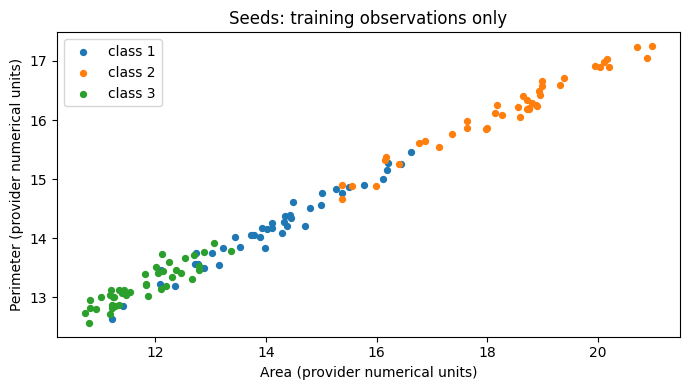

In [6]:
plt.figure(figsize=(7,4))
for label in [1,2,3]:
    ix=train[y[train]==label]
    plt.scatter(X[ix,0],X[ix,1],label=f'class {label}',s=18)
plt.xlabel('Area (provider numerical units)');plt.ylabel('Perimeter (provider numerical units)')
plt.title('Seeds: training observations only');plt.legend();plt.tight_layout()
show_and_save(OUT/'training_geometry.png')


## Advanced return: topology of a feature cloud
Use the first 24 sorted training row identities, selected without consulting outcomes or diagrams. All seven standardized features define the metric. This is descriptive, not a new predictive feature or a claim of physical grain holes.

In [7]:
from shape_lab.persistence import rips_filtration,persistent_homology,diagram
subset=np.sort(train)[:24];scaler=StandardScaler().fit(X[train]);cloud=scaler.transform(X[subset])
intervals=persistent_homology(rips_filtration(cloud,max_homology=1),max_dim=1)
records=[{'dim':a.dim,'birth':float(a.birth),'death':None if np.isinf(a.death) else float(a.death)} for a in intervals]
print('Subset source IDs:',table.source_id.iloc[subset].tolist())
print('Positive finite H1 intervals:',diagram(intervals,1,finite_only=True))
save_json(OUT/'persistence.json',{'source_ids':table.source_id.iloc[subset].tolist(),'intervals':records,'infinite_death_encoding':None})


Subset source IDs: [1, 3, 6, 9, 10, 12, 13, 14, 15, 17, 19, 20, 22, 24, 25, 26, 27, 29, 30, 34, 36, 37, 41, 43]
Positive finite H1 intervals: [[0.93822019 0.97645698]
 [1.52640744 1.53272266]]


## Record the scope, not just the score
Read the model errors before opening the separate solutions. These test labels are now exposed; later tuning needs a newly justified evaluation protocol.

In [8]:
fitted={}
for name,(model,cols) in models.items():
    if hasattr(model,'named_steps'):
        z=model.named_steps['standardscaler'];m=model.named_steps['logisticregression']
        fitted[name]={'feature_indices':cols,'center':z.mean_.tolist(),'scale':z.scale_.tolist(),'coef':m.coef_.tolist(),'intercept':m.intercept_.tolist(),'classes':m.classes_.tolist()}
save_json(OUT/'fitted_parameters.json',fitted)
save_json(OUT/'results.json',{'source_numeric_sha256':meta['numeric_sha256'],'n':len(table),'metrics':metrics,'compactness_max_abs_gap':float(compactness_gap.max()),'scope':'Fixed within-collection demonstration. No farm/batch independence; no predictive TDA comparison in this lab.'})
save_json(OUT/'protocol.json',{'seed':17,'features':meta['features'],'split_sizes':{k:len(v) for k,v in parts.items()},'models':'fixed C=1; same rows; no tuning','persistence_subset':'first 24 sorted training row indices','data_acquisition':meta['acquisition'],'split_audit':audit})
print('Saved protocol, splits, predictions, metrics and diagram records.')


Saved protocol, splits, predictions, metrics and diagram records.
